In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv("original_dataset.csv")

print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Information")
print(df.info())

print("\nSummary Statistics")
print(df.describe())

First 5 Rows
   age  gender marital_status education_level  annual_income  monthly_income  \
0   59    Male        Married        Master's       24240.19         2020.02   
1   72  Female        Married      Bachelor's       20172.98         1681.08   
2   49  Female         Single     High School       26181.80         2181.82   
3   35  Female         Single     High School       11873.84          989.49   
4   63   Other         Single           Other       25326.44         2110.54   

  employment_status  debt_to_income_ratio  credit_score  loan_amount  ...  \
0          Employed                 0.074           743     17173.72  ...   
1          Employed                 0.219           531     22663.89  ...   
2          Employed                 0.234           779      3631.36  ...   
3          Employed                 0.264           809     14939.23  ...   
4          Employed                 0.260           663     16551.71  ...   

  loan_term  installment  grade_subgrade  n

In [3]:
print("\nMissing Values")
print(df.isnull().sum())

# Fill missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

print("\nDataset Shape After Cleaning")
print(df.shape)


Missing Values
age                     0
gender                  0
marital_status          0
education_level         0
annual_income           0
monthly_income          0
employment_status       0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
loan_purpose            0
interest_rate           0
loan_term               0
installment             0
grade_subgrade          0
num_of_open_accounts    0
total_credit_limit      0
current_balance         0
delinquency_history     0
public_records          0
num_of_delinquencies    0
loan_paid_back          0
dtype: int64

Dataset Shape After Cleaning
(20000, 22)


/tmp/ipykernel_564/205162189.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_564/205162189.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

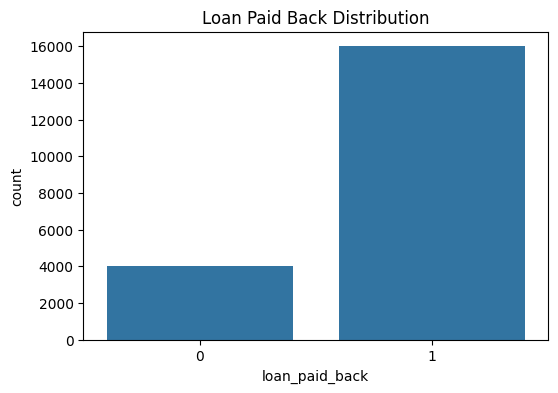

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x='loan_paid_back', data=df)
plt.title("Loan Paid Back Distribution")
plt.show()

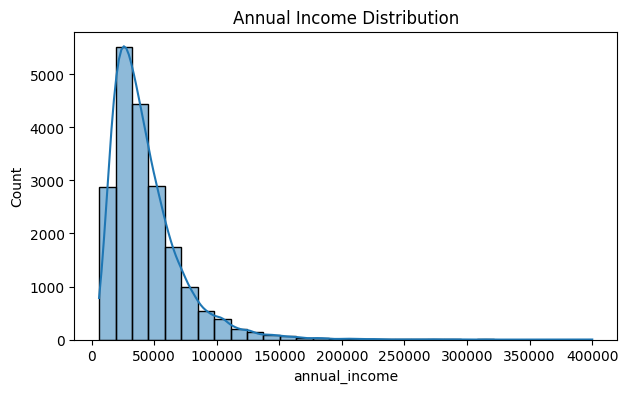

In [5]:
plt.figure(figsize=(7,4))
sns.histplot(df['annual_income'], bins=30, kde=True)
plt.title("Annual Income Distribution")
plt.show()

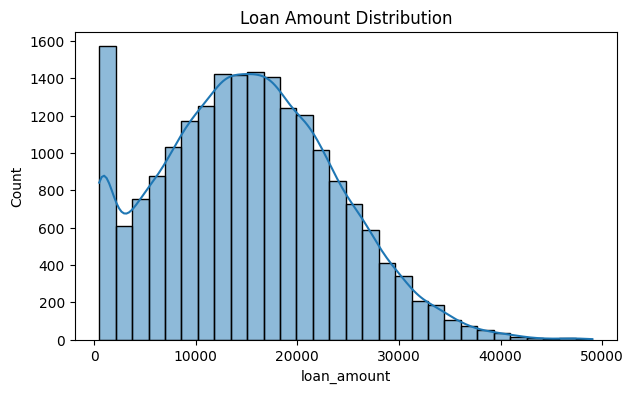

In [6]:
plt.figure(figsize=(7,4))
sns.histplot(df['loan_amount'], bins=30, kde=True)
plt.title("Loan Amount Distribution")
plt.show()


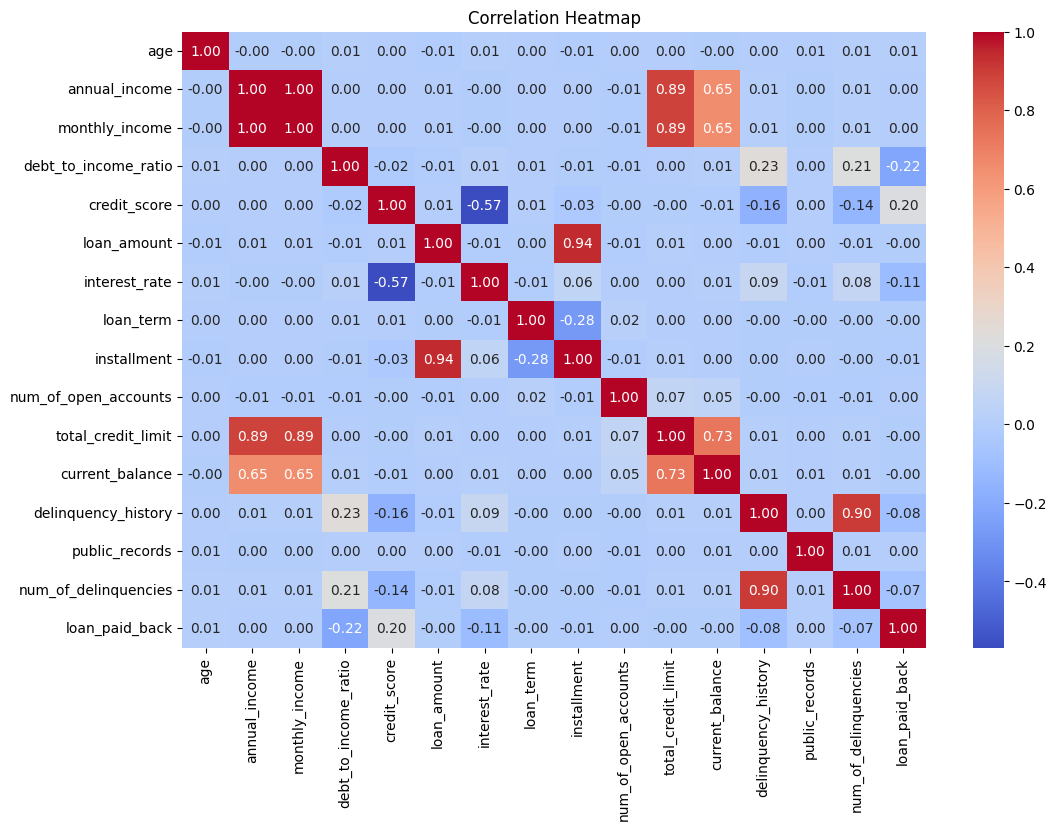

In [7]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [8]:
encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = encoder.fit_transform(df[col])

In [9]:
X = df.drop("loan_paid_back", axis=1)
y = df["loan_paid_back"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])



Training Samples : 16000
Testing Samples : 4000


In [12]:
model = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [13]:
y_pred = model.predict(X_test)

In [14]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy :", accuracy)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)


Accuracy : 0.83525

Classification Report
              precision    recall  f1-score   support

           0       0.60      0.60      0.60       818
           1       0.90      0.89      0.90      3182

    accuracy                           0.84      4000
   macro avg       0.75      0.75      0.75      4000
weighted avg       0.84      0.84      0.84      4000


Confusion Matrix
[[ 494  324]
 [ 335 2847]]


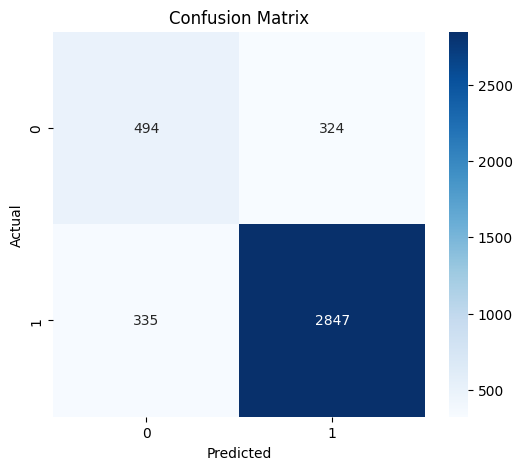

In [15]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Feature Importance
                 Feature  Importance
6      employment_status    0.348502
7   debt_to_income_ratio    0.121581
8           credit_score    0.117351
11         interest_rate    0.049968
9            loan_amount    0.044168
17       current_balance    0.042575
13           installment    0.039549
0                    age    0.035282
16    total_credit_limit    0.033209
4          annual_income    0.025147
5         monthly_income    0.023516
15  num_of_open_accounts    0.018409
14        grade_subgrade    0.017732
3        education_level    0.015542
10          loan_purpose    0.015473
18   delinquency_history    0.015064
20  num_of_delinquencies    0.013025
2         marital_status    0.011550
1                 gender    0.005982
19        public_records    0.004584
12             loan_term    0.001792


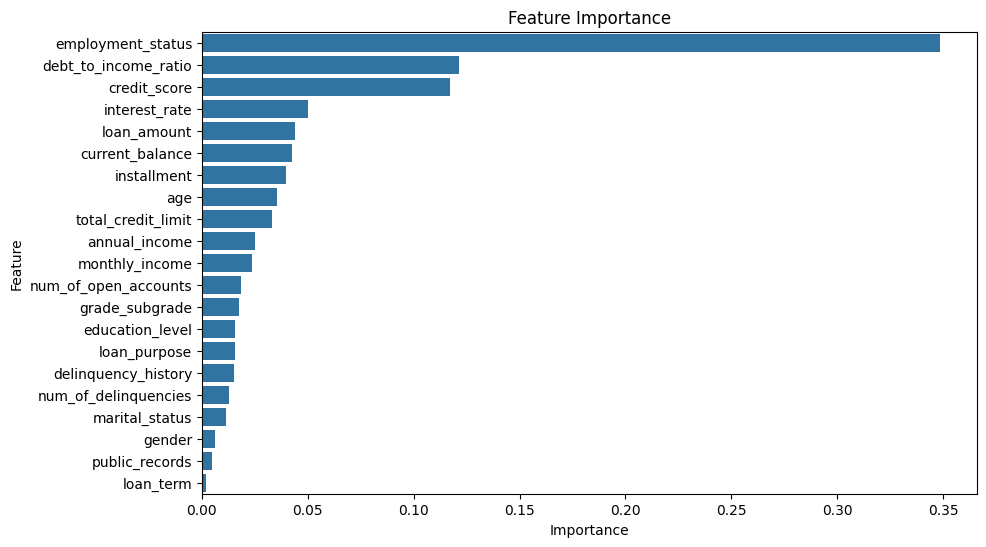

In [16]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance")
print(importance)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()


In [17]:
sample = X.iloc[[0]]

prediction = model.predict(sample)

print("\nPrediction for First Customer")

if prediction[0] == 1:
    print("Loan will be Paid Back")
else:
    print("Loan may Default")


Prediction for First Customer
Loan will be Paid Back
